In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyreadstat
# !pip install pyreadstat
import json
import os, glob

### BRFSS Preprocessing

In [24]:
# Read the XPT file using pyreadstat
df, meta = pyreadstat.read_xport('BRFSS/BFRSS2021.XPT')

In [15]:
# store column name and labels pair 
column_names=meta.column_names_to_labels
with open('BRFSS/BRFSS_column_labels.json', 'w') as json_file:
    json.dump(column_names, json_file, indent=1, separators=(',', ': '))
print(f"shape of BRFSS 2021: {df.shape}")
print(f"number of columns: {len(column_names)}")

shape of BRFSS 2021: (438693, 303)
number of columns: 303


In [16]:
# common_col = ['_STATE', 'IYEAR', '_AGE80', '_SEX', 'BPHIGH6', 'DIABETE4', 'CHCKDNY2', 'NUMADULT', 'INCOME3', 'CHILDREN', 'EDUCA', 'MARITAL', 'PREGNANT', '_BMI5']
common_col =  ['_STATE', 'IYEAR', '_AGE80', '_SEX', 'CHCKDNY2', 'DIABETE4', 'NUMADULT', 'INCOME3', 'CHILDREN', 'EDUCA', 'MARITAL', 'PREGNANT', '_BMI5'] # remove BPHIGH6, DIABETE4
add_col = ['_RFHLTH', '_URBSTAT', '_PHYS14D', '_MENT14D', '_TOTINDA', '_SMOKER3']
common_col = common_col + add_col

In [76]:
# get 2022 and 2023 data
df_2022 = pd.read_sas('BRFSS/LLCP2022.XPT')    
df_2022 = df_2022[common_col]
df_2023 = pd.read_sas('BRFSS/LLCP2023.XPT')
df_2023 = df_2023[common_col]

c:\Users\frank\anaconda3\envs\deep_learning\lib\site-packages\pandas\io\sas\sas_xport.py:475: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df[x] = v


In [ ]:
df_train = pd.concat([df[common_col], df_2022, df_2023], axis=0)

In [138]:
df_train['_BMI5'] = df_train['_BMI5'] / 100 

In [139]:
df_train.head()

,_STATE,IYEAR,_AGE80,_SEX,CHCKDNY2,DIABETE4,NUMADULT,INCOME3,CHILDREN,EDUCA,MARITAL,PREGNANT,_BMI5,_RFHLTH,_URBSTAT,_PHYS14D,_MENT14D,_TOTINDA,_SMOKER3
0,1.0,2021,70.0,2.0,2.0,3.0,2.0,5.0,88.0,4.0,1.0,NaN,14.54,2.0,1.0,3.0,2.0,2.0,3.0
1,1.0,2021,67.0,2.0,1.0,1.0,2.0,77.0,88.0,6.0,9.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,4.0
2,1.0,2021,72.0,2.0,2.0,1.0,2.0,3.0,88.0,4.0,3.0,NaN,28.29,1.0,1.0,1.0,1.0,2.0,4.0
3,1.0,2021,62.0,2.0,2.0,1.0,2.0,7.0,88.0,4.0,1.0,NaN,33.47,1.0,1.0,1.0,2.0,1.0,4.0
4,1.0,2021,76.0,1.0,2.0,1.0,2.0,4.0,88.0,3.0,1.0,NaN,28.73,2.0,1.0,3.0,1.0,1.0,4.0


In [140]:
df_train = df_train.dropna()

Numeric: poverty_index, '_DRNKWK1', '_FRUTSU1', 'FRNCHDA_', 'POTADA1_', '_VEGESU1', '_BMI5'

In [141]:
df_train['_BMI5'].mean()

29.007255345201134

In [26]:
df_train['_DRNKWK1'].replace(99900, np.nan, inplace=True)

c:\Users\frank\anaconda3\envs\deep_learning\lib\site-packages\pandas\core\generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [27]:
# get number of people in household
df_train['CHILDREN'].replace(88, 0, inplace=True)
df_train = df_train[df_train['CHILDREN'] < 99] 
df_train['NUMPEOPLE'] = df_train['NUMADULT'] + df_train['CHILDREN']
 # calculate poverty level
df_train = df_train.dropna(subset=['NUMPEOPLE', 'INCOME3'])
df_train['NUMPEOPLE'].value_counts()
# drop 102, 78 and 57 
df_train = df_train[df_train['NUMPEOPLE'] < 50]

In [28]:
df_train['IYEAR'] = df_train['IYEAR'].astype(int)
df_train['IYEAR'].value_counts()

2021    111132
2022      3845
Name: IYEAR, dtype: int64

In [29]:
# define 2021 federal poverty level per household size, more than 8 people, add 4540 for each additional person, write up to 16 people
fpl_2021 = {1: 12880, 2: 17420, 3: 21960, 4: 26500, 5: 31040, 6: 35580, 7: 40120, 8: 44660}
fpl_2022 = {1: 13590, 2: 18310, 3: 23030, 4: 27750, 5: 32470, 6: 37190, 7: 41910, 8: 46630}
fpl_2023 = {1: 14580, 2: 19720, 3: 24860, 4: 30000, 5: 35140, 6: 40280, 7: 45420, 8: 50560}
fpl_2024 = {1: 15060, 2: 20440, 3: 25820, 4: 31200, 5: 36580, 6: 41960, 7: 47340, 8: 52720}
def fpl_level(num_people, year):
    if num_people > 8:
        if year == 2021:
            return 44660 + 4540*(num_people-8)
        elif year == 2023:
            return 50560 + 5140*(num_people-8)
        elif year == 2024:
            return 52720 + 5380*(num_people-8)
        elif year == 2022:
            return 46630 + 4720*(num_people-8)
    else:
        if year == 2021:
            return fpl_2021[num_people]
        elif year == 2023:
            return fpl_2023[num_people]
        elif year == 2024:
            return fpl_2024[num_people]
        elif year == 2022:
            return fpl_2022[num_people]

# convert income category to income 
def get_income(income_cat):
    if income_cat == 1:
        return 7500 
    elif income_cat == 2:
        return (15000 + 25000)/2
    elif income_cat == 3:
        return (25000 + 35000)/2
    elif income_cat == 4:
        return (35000 + 50000)/2
    elif income_cat == 5:
        return (50000 + 100000)/2
    elif income_cat == 6:
        return (100000 + 200000)/2
    elif income_cat == 7:
        return 200000
    else:
        return 
# convert income to poverty level 
df_train['INCOME'] = df_train['INCOME3'].apply(get_income)
# Convert FPL based on the year
df_train['FPL'] = df_train.apply(lambda row: fpl_level(row['NUMPEOPLE'], row['IYEAR']), axis=1)
df_train['FPL_RATIO'] = df_train['INCOME']/df_train['FPL']
df_train['FPL_RATIO'] = df_train['FPL_RATIO'].apply(lambda x: 5 if x > 5 else x)
df_train.drop(columns=['FPL', 'NUMPEOPLE', 'CHILDREN', 'NUMADULT'], inplace=True)
df_train.head()

,_STATE,IYEAR,_AGE80,_SEX,BPHIGH6,DIABETE4,CHCKDNY2,INCOME3,EDUCA,MARITAL,...,_MICHD,_LTASTH1,_LMTACT3,_SMOKER3,_DRNKWK1,_FRUTSU1,FRNCHDA_,POTADA1_,INCOME,FPL_RATIO
0,1.0,2021,70.0,2.0,3.0,3.0,2.0,5.0,4.0,1.0,...,2.0,2.0,2.0,3.0,0.0,100.0,43.0,14.0,75000.0,4.305396
1,1.0,2021,67.0,2.0,1.0,1.0,1.0,77.0,6.0,9.0,...,1.0,1.0,1.0,4.0,0.0,100.0,0.0,14.0,NaN,NaN
2,1.0,2021,72.0,2.0,1.0,1.0,2.0,3.0,4.0,3.0,...,1.0,1.0,3.0,4.0,0.0,100.0,14.0,14.0,30000.0,1.722158
3,1.0,2021,62.0,2.0,1.0,1.0,2.0,7.0,4.0,1.0,...,2.0,1.0,3.0,4.0,300.0,114.0,57.0,27.0,200000.0,5.000000
4,1.0,2021,76.0,1.0,4.0,1.0,2.0,4.0,3.0,1.0,...,1.0,1.0,3.0,4.0,0.0,100.0,29.0,29.0,42500.0,2.439724


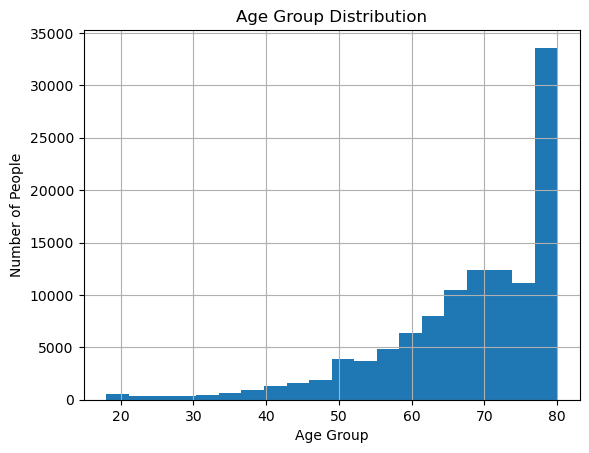

In [30]:
# plot histogram of age_G
df_train['_AGE80'].hist(bins=20)
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.show()

In [31]:
df_train['_BMI5'].value_counts()

26.63    1230
27.46    1042
27.44     995
24.41     732
28.34     693
         ... 
22.88       1
43.51       1
59.41       1
33.32       1
41.30       1
Name: _BMI5, Length: 2723, dtype: int64

In [32]:
# convert marital status to match with NHANES, 1,6->1, 2,3,4_>2, 5->3 
def process_marital(x):
    if x in [1,6]:
        return 1
    elif x in [2,3,4]:
        return 2
    elif x == 5:
        return 3
    else:
        return 
df_train['MARITAL'] = df_train['MARITAL'].apply(process_marital)
df_train['MARITAL'].value_counts()

1.0    59928
2.0    42388
3.0    11702
Name: MARITAL, dtype: int64

In [33]:
# df_train['_HLTHPLN'].value_counts()

In [34]:
# standardize health insurance
df_train = df_train[df_train['_HLTHPLN']!=9]

In [35]:
# standadize chronic kidney disease, select 1 and 2
df_train = df_train[(df_train['CHCKDNY2']==1) | (df_train['CHCKDNY2']==2)]

In [36]:
def process_weight(value):
    if value == 7777 or value == 9999 :  # Handle None values
        return np.nan
    if value < 1000:  # Convert pounds to kilograms
        kg = value * 0.453592
        return round(kg, 2)  # Round to two decimal places
    elif 9000 < value < 9400:  # Remove leading '9'
        return float(str(value)[1:])  # Remove the first character
    return np.nan  # Return None for all other values
# df_train['Weight'] = df_train['WEIGHT2'].apply(process_weight)
# df_train = df_train.drop(columns=['WEIGHT2'])
def process_height(value):
    if value == 7777 or value == 9999 :  # Handle None values
        return np.nan
    if value < 1000:  # Convert pounds to kilograms
        feet = float(str(value)[0])
        inch = float(str(value)[1:])
        cm = inch * 2.54 + feet * 30.48
        return round(cm, 2)  # Round to two decimal places
    elif 9000 < value < 9400:  # Remove leading '9'
        return float(str(value)[1:])  # Remove the first character
    return np.nan  # Return None for all other values
# df_train['Height'] = df_train['HEIGHT3'].apply(process_height)
# df_train = df_train.drop(columns=['HEIGHT3'])

In [37]:
def process_race(value):
    # convert American Indians 3, Pacific Islanders 5, other races 6, multiracial 7 to 5 
    if value == 3 or value == 6 or value ==7:
        return 5
    # convert Hispanic 8 to 3 
    elif value == 8:
        return 3 
    else:
        return value
df_train['_RACEPRV'] = df_train['_RACEPRV'].apply(process_race)
df_train['_RACEPRV'].value_counts()    

1.0    93612
2.0     7575
5.0     4441
3.0     2964
4.0     1473
Name: _RACEPRV, dtype: int64

In [38]:
# df_train['BMI'] = df_train['Weight'] / ((df_train['Height']/100) ** 2)
# df_train.head()

In [39]:
# remove unknown BP status, DM status and convert to binary: 3-->2 
df_train = df_train[(df_train['BPHIGH6'] == 1) | (df_train['BPHIGH6'] == 3)]
df_train['BPHIGH6'] = df_train['BPHIGH6'].replace(3, 2)
df_train = df_train[(df_train['DIABETE4'] == 1) | (df_train['DIABETE4'] == 3)] 
df_train['DIABETE4'] = df_train['DIABETE4'].replace(3, 2)
# remove non adult (age<18)
# df_train = df_train[df_train['CADULT1'] == 1]
# remove pregnant responder and drop the column 
df_train = df_train[df_train['PREGNANT'] != 1]
df_train = df_train.drop(columns=['PREGNANT'])

In [40]:
# change education status to match NHANES
value_mapping = {
    1: 1,  # Never attended school or only kindergarten
    2: 1,  # Grades 1 through 8
    3: 2,  # Grades 9 through 11
    4: 3,  # high school graduate or GED
    5: 4,  # Some college or technical school
    6: 5   # College graduate
}
df_train['EDUCA'] = df_train['EDUCA'].replace(value_mapping)

# Remove rows where 'EDUCA' is 9(refuse) or NaN
df_train = df_train[df_train['EDUCA'].notna() & (df_train['EDUCA'] != 9)]

In [41]:
df_train = df_train.rename(columns={
    'CADULT1': 'Is_Adult',
    '_SEX': 'Gender',     # 1: Male, 2: Female  
    'BPHIGH6': 'Hypertension',
    'DIABETE4': 'Diabetes',
    'EDUCA': 'Education',
    '_RACEPRV': 'Race',
    '_AGE80': 'Age',
    'MARITAL': 'Marriage',
    '_HLTHPLN': 'Health_Insurance',
    'CHCKDNY2': 'CKD',
    'FPL_RATIO': 'Poverty_Index',
    '_BMI5': 'BMI'
})
# df_train = df_train.drop(columns=['IYEAR'])
# bmi = df_train['BMI']
# df_train = df_train.drop(columns=['BMI'])
# df_train['BMI'] = bmi

In [42]:

df_train = df_train.dropna()

In [43]:
df_train.shape

(40620, 30)

In [44]:
df_train['Race'].value_counts()

1.0    34439
2.0     3131
5.0     1651
3.0     1041
4.0      358
Name: Race, dtype: int64

In [45]:
df_train['Hypertension'].value_counts()    

1.0    24368
2.0    16252
Name: Hypertension, dtype: int64

In [46]:
df_train.head()

,_STATE,IYEAR,Age,Gender,Hypertension,Diabetes,CKD,INCOME3,Education,Marriage,...,_MICHD,_LTASTH1,_LMTACT3,_SMOKER3,_DRNKWK1,_FRUTSU1,FRNCHDA_,POTADA1_,INCOME,Poverty_Index
0,1.0,2021,70.0,2.0,2.0,2.0,2.0,5.0,3.0,1.0,...,2.0,2.0,2.0,3.0,0.0,100.0,43.0,14.0,75000.0,4.305396
2,1.0,2021,72.0,2.0,1.0,1.0,2.0,3.0,3.0,2.0,...,1.0,1.0,3.0,4.0,0.0,100.0,14.0,14.0,30000.0,1.722158
3,1.0,2021,62.0,2.0,1.0,1.0,2.0,7.0,3.0,1.0,...,2.0,1.0,3.0,4.0,300.0,114.0,57.0,27.0,200000.0,5.000000
5,1.0,2021,80.0,1.0,2.0,2.0,2.0,6.0,4.0,1.0,...,2.0,1.0,3.0,3.0,0.0,29.0,0.0,14.0,150000.0,5.000000
10,1.0,2021,67.0,2.0,1.0,2.0,2.0,3.0,4.0,2.0,...,2.0,2.0,3.0,2.0,0.0,43.0,14.0,0.0,30000.0,2.329193


In [47]:
df_train['INCOME3'].value_counts()

7.0    11776
6.0    10145
5.0     8680
4.0     4115
3.0     2768
2.0     2000
1.0     1136
Name: INCOME3, dtype: int64

In [48]:
# df_train.to_csv('BRFSS/BRFSS_2021_2023.csv', index=False)
# df_train.to_csv('BRFSS/BRFSS_2021.csv', index=False)
# df_train.to_csv('BRFSS/BRFSS_2021_long.csv', index=False)
df_train.to_csv('BRFSS/BRFSS_2021_long.csv', index=False)

In [51]:
# create json file for column names and labels
variables_meta = {
    'Race': {
        1: 'White',
        2: 'Black',
        3: 'Hispanic',
        4: 'Asian',
        5: 'Other'
    },
    'Gender': {
        1: 'Male', 
        2: 'Female'
    },
    'Education': {
        1: 'Less than high school',
        2: 'some high school',
        3: 'high school graduate',
        4: 'some college',
        5: 'college graduate'
    },
    'Hypertension': {
        1: 'Yes',
        2: 'No'
    },
    'Diabetes': {
        1: 'Yes',
        2: 'No'
    },
    'Marrige': {
        1: 'Married or living with partner',
        2: 'divorced or separated or widowed',
        3: 'never married'
    },
    'Health_Insurance': {
        1: 'Yes',
        2: 'No'
    },
    'CKD': {
        1: 'Yes',
        2: 'No'
    },
    'Age': {
        1: '18-24',
        2: '25-34',
        3: '35-44',
        4: '45-54',
        5: '55-64',
        6:  '>='
    },
}
with open('BRFSS/BRFSS_variables_meta.json', 'w') as json_file:
    json.dump(variables_meta, json_file, indent=1, separators=(',', ': '))


### NHANES 2021-2023 Preprocessing

In [142]:
data_path = os.path.join("NHANES", "2021-2023")
file_pattern = os.path.join(data_path, "*.XPT")

# Use glob to find files that match the pattern
files = glob.glob(file_pattern)

In [143]:
demo_df = pd.read_sas(os.path.join(data_path, "DEMO_L.XPT"))
print(demo_df.shape)
print(demo_df.columns)

(11933, 27)
Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4',
       'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND',
       'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR',
       'SDMVSTRA', 'SDMVPSU', 'INDFMPIR'],
      dtype='object')


In [144]:
demo_df_select = demo_df[['SEQN', 'RIAGENDR', 'RIDAGEYR', 
       'RIDRETH3', 'DMDEDUC2', 'DMDMARTZ',  'DMDHHSIZ',  'INDFMPIR', ]]
demo_df_select.head()

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH3,DMDEDUC2,DMDMARTZ,DMDHHSIZ,INDFMPIR
0,130378.0,1.0,43.0,6.0,5.0,1.0,4.0,5.00
1,130379.0,1.0,66.0,3.0,5.0,1.0,2.0,5.00
2,130380.0,2.0,44.0,2.0,3.0,1.0,7.0,1.41
3,130381.0,2.0,5.0,7.0,NaN,NaN,2.0,1.53
4,130382.0,1.0,2.0,3.0,NaN,NaN,4.0,3.60


In [145]:
bmi_df = pd.read_sas(os.path.join(data_path, "BodyMeasure_L.XPT"))
print(bmi_df.shape)
print(bmi_df.columns)

(8860, 22)
Index(['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD',
       'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG',
       'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST',
       'BMXHIP', 'BMIHIP'],
      dtype='object')


In [146]:
bmi_df_valid = bmi_df[['SEQN', 'BMXBMI']]
# filter out rows with comments(invalid) or does not have weight or height 
# bmi_valid = bmi_df_select[bmi_df_select["BMIWT"].isna() &
#                           bmi_df_select["BMIHT"].isna() & 
#                           bmi_df_select["BMXWT"].notna() &
#                           bmi_df_select["BMXHT"].notna()]
# Drop 'BMIWT' and 'BMIHT' columns
# bmi_df_valid = bmi_valid.drop(['BMIWT', 'BMIHT'], axis=1)
bmi_df_valid.head()

,SEQN,BMXBMI
0,130378.0,27.0
1,130379.0,33.5
2,130380.0,29.7
3,130381.0,23.8
4,130382.0,NaN


In [147]:
bmi_df_valid['BMXBMI'].mean()

27.24666509266917

In [148]:
df_train = df_train[df_train['_BMI5'] >= 18.5]
bmi_df_valid = bmi_df_valid[bmi_df_valid['BMXBMI'] >= 18.5]
# Define the BMI intervals
intervals = [(18.5, 20), (20, 30), (30, 35), (35, 40), (40, np.inf)]

# Initialize dictionaries to store means for each interval in both datasets
means_train = {}
means_valid = {}

for lower, upper in intervals:
    # Calculate the mean for each interval in the training dataset
    if upper == np.inf:
        means_train[f'>{lower}'] = np.mean(df_train['_BMI5'] > lower)
        means_valid[f'>{lower}'] = np.mean(bmi_df_valid['BMXBMI'] > lower)
    else:
        means_train[f'{lower}-{upper}'] = np.mean((df_train['_BMI5'] > lower) & (df_train['_BMI5'] <= upper))
        means_valid[f'{lower}-{upper}'] = np.mean((bmi_df_valid['BMXBMI'] > lower) & (bmi_df_valid['BMXBMI'] <= upper))

print("self reported BMI ratio by Interval:")
for interval, mean in means_train.items():
    print(f"{interval}: {mean:.4f}")

print("measured Dataset BMI ratio by Interval:")
for interval, mean in means_valid.items():
    print(f"{interval}: {mean:.4f}")


self reported BMI ratio by Interval:
18.5-20: 0.0414
20-30: 0.5860
30-35: 0.1830
35-40: 0.0967
>40: 0.0929
measured Dataset BMI ratio by Interval:
18.5-20: 0.0579
20-30: 0.5728
30-35: 0.1897
35-40: 0.0937
>40: 0.0830


In [149]:
df_train['_BMI5'].mean()

29.211037093836914

In [150]:
bmi_df_valid['BMXBMI'].mean()

29.054934029686727

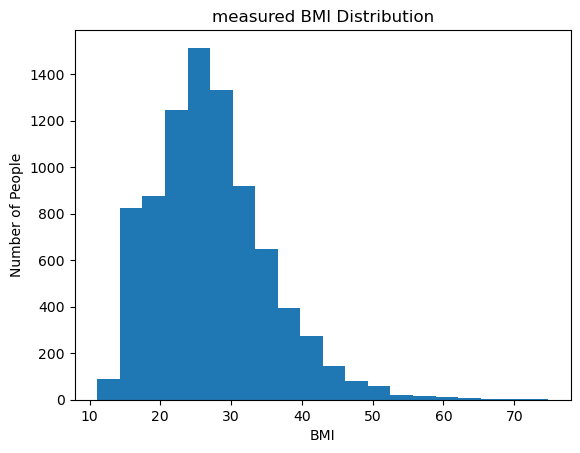

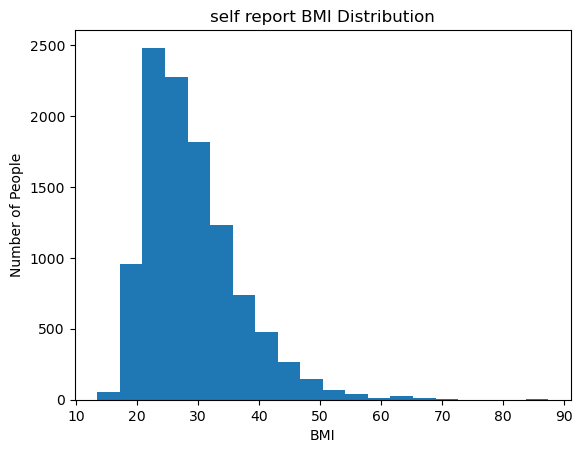

In [82]:
plt.hist(bmi_df_valid['BMXBMI'], bins=20)
plt.title('measured BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Number of People')

plt.show()

plt.hist(df_train['_BMI5'], bins=20)
plt.title('self report BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Number of People')

plt.show()

In [83]:
print(df_train['_BMI5'].mean())
print(bmi_df_valid['BMXBMI'].mean())

29.007255345201134
27.24666509266917


In [84]:
# Merge two DataFrames on the 'SEQN' column
merge_df = pd.merge(demo_df_select, bmi_df_valid, on='SEQN')
print(merge_df.shape)
merge_df.head()

(8860, 9)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH3,DMDEDUC2,DMDMARTZ,DMDHHSIZ,INDFMPIR,BMXBMI
0,130378.0,1.0,43.0,6.0,5.0,1.0,4.0,5.00,27.0
1,130379.0,1.0,66.0,3.0,5.0,1.0,2.0,5.00,33.5
2,130380.0,2.0,44.0,2.0,3.0,1.0,7.0,1.41,29.7
3,130381.0,2.0,5.0,7.0,NaN,NaN,2.0,1.53,23.8
4,130382.0,1.0,2.0,3.0,NaN,NaN,4.0,3.60,NaN


In [103]:
# Rename columns in the DataFrame
merge_df = merge_df.rename(columns={
    'RIAGENDR': 'Gender',
    'RIDAGEYR': 'Age',
    'RIDRETH3': 'Race',
    'DMDEDUC2': 'Education',
    'DMDMARTZ': 'Marriage',
    'INDFMPIR': 'Poverty_Index',
    'BMXBMI': 'BMI'
})


In [104]:
# convert race to match BRFSS
def process_race_NHA(n):
    if n == 1 or n == 2:
        return 'Hispanic'
    elif n == 3:
        return 'White' # White
    elif n == 4:
        return 'Black' # Black
    elif n == 6:
        return 'Asian' # Asian
    elif n == 7:
        return 'Other' # Other
    else:
        return 
merge_df['Race'] = merge_df['Race'].apply(process_race_NHA)
merge_df['Race'].value_counts()

White       4684
Hispanic    1841
Black       1159
Other        647
Asian        529
Name: Race, dtype: int64

### Subgroup analysis of  NHANES data

In [105]:
merge_df.shape

(8860, 9)

In [ ]:
# race level analysis
mean_bmi_national = merge_df['BMI'].mean()
mean_bmi_per_race = merge_df.groupby('Race')['BMI'].mean()
print(f'mean bmi national 2021-2023: {mean_bmi_national}')
print('mean bmi per race 2021-2023')
print(mean_bmi_per_race)
# convert to csv
merge_df.to_csv('NHANES/NHANES_2021_2023_race.csv', index=False)

mean bmi national 2021-2023: 27.24666509266917
mean bmi per race 2021-2023
Race
Asian       23.011133
Black       28.503755
Hispanic    26.708094
Other       26.792471
White       27.682976
Name: BMI, dtype: float64


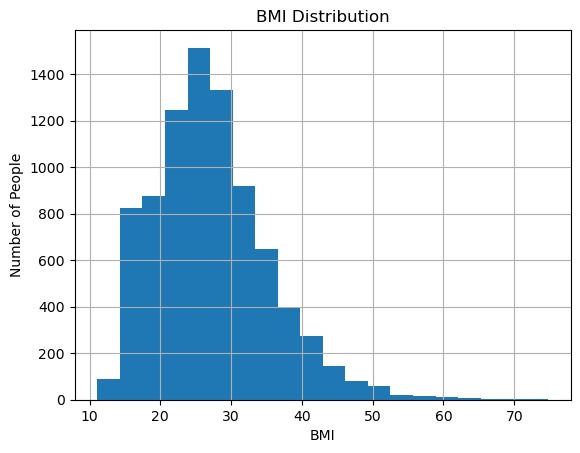

In [94]:
# histogram of BMI
merge_df['BMI'].hist(bins=20)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Number of People')
plt.show()


In [58]:
merge_df['Education'].value_counts()

5.0    2143
4.0    1846
3.0    1297
2.0     482
1.0     292
9.0       4
Name: Education, dtype: int64

In [59]:
# remove unknown education status 
merge_df = merge_df[(merge_df['Education'] != 9) & (merge_df['Education'].notna()) & (merge_df['Education'] != 7)]

In [60]:
# standardize marital status to match BRFSS, only select 1,2,3
print(merge_df['Marriage'].value_counts())
def process_marital_NHA(x):
    if x == 1:
        return 1
    elif x == 2:
        return 2
    elif x == 3:
        return 3
    else:
        return
merge_df['Marriage'] = merge_df['Marriage'].apply(process_marital_NHA)
merge_df['Marriage'].value_counts()

1.0     3277
2.0     1533
3.0     1245
99.0       3
77.0       1
Name: Marriage, dtype: int64


1.0    3277
2.0    1533
3.0    1245
Name: Marriage, dtype: int64

In [126]:
merge_df.head()

,SEQN,Gender,Age,Race,Education,Marriage,DMDHHSIZ,Poverty_Index,BMI
0,130378.0,1.0,43.0,4,5.0,1.0,4.0,5.00,27.0
1,130379.0,1.0,66.0,1,5.0,1.0,2.0,5.00,33.5
2,130380.0,2.0,44.0,3,3.0,1.0,7.0,1.41,29.7
5,130386.0,1.0,34.0,3,4.0,1.0,3.0,1.33,30.2
6,130387.0,2.0,68.0,1,5.0,3.0,1.0,1.32,42.6


In [127]:
# extract hypertension status 
variables_meta["BPQ020"] =  {
    "Description": "Ever told you had high blood pressure",
    "Values": {
      "1": "Yes",
      "2": "No",
      "7": "Refused",
      "9": "Don't know",
      ".": "Missing"
    }
  } 

df_htn = pd.read_sas(os.path.join(data_path, "BPchol_L.XPT"))
print(df_htn.shape)
df_htn = df_htn[['SEQN', 'BPQ020']]
df_htn = df_htn[(df_htn['BPQ020'] == 1) | (df_htn['BPQ020'] == 2)]

(8501, 6)


In [128]:
# extract DM status 
variables_meta["DIQ010"] = {  "Description": "Doctor told you have diabetes",
    "Values": {
      "1": "Yes",
      "2": "No",
      "3": "Borderline",
      "7": "Refused",
      "9": "Don't know",
      ".": "Missing"
    }
  }
df_dm = pd.read_sas(os.path.join(data_path, "DiabetesQ_L.XPT"))
print(df_dm.shape)
df_dm = df_dm[['SEQN', 'DIQ010']]
df_dm.loc[df_dm['DIQ010'] == 3, 'DIQ010'] = 1
df_dm = df_dm[(df_dm['DIQ010'] == 1) | (df_dm['DIQ010'] == 2)]
print(df_dm.shape)
df_dm.head()

(11744, 9)
(11736, 2)


,SEQN,DIQ010
0,130378.0,2.0
1,130379.0,2.0
2,130380.0,1.0
3,130381.0,2.0
4,130382.0,2.0


In [129]:
# extract health insurance status
df_hiq = pd.read_sas(os.path.join(data_path, "HIQ_L.XPT"))
df_hiq = df_hiq[['SEQN', 'HIQ011']]
df_hiq = df_hiq[(df_hiq['HIQ011'] == 1) | (df_hiq['HIQ011'] == 2)]

In [130]:
# extract CKD status
df_ckd = pd.read_sas(os.path.join(data_path, "KIQ_U_L.XPT"))
df_ckd = df_ckd[['SEQN', 'KIQ022']]
df_ckd = df_ckd[(df_ckd['KIQ022'] == 1) | (df_ckd['KIQ022'] == 2)]

In [131]:
# merge with the main dataframe
merge_df = pd.merge(merge_df, df_htn, on='SEQN')
merge_df = pd.merge(merge_df, df_dm, on='SEQN')
merge_df = pd.merge(merge_df, df_hiq, on='SEQN')
merge_df = pd.merge(merge_df, df_ckd, on='SEQN')
merge_df = merge_df.rename(columns={
    'BPQ020': 'Hypertension',
    'DIQ010': 'Diabetes',
    'HIQ011': 'Health_Insurance',
    'KIQ022': 'CKD',
    'DMDHHSIZ': 'Household_Size',
})

In [132]:
# drop na values and drop SEQN column
merge_df = merge_df.drop(columns=['SEQN', 'Household_Size'])
merge_df = merge_df.dropna()
bmi = merge_df['BMI']
merge_df = merge_df.drop(columns=['BMI'])
merge_df['BMI'] = bmi

In [134]:
merge_df.head()

,Gender,Age,Race,Education,Marriage,Poverty_Index,Hypertension,Diabetes,Health_Insurance,CKD,BMI
0,1.0,43.0,4,5.0,1.0,5.00,1.0,2.0,1.0,2.0,27.0
1,1.0,66.0,1,5.0,1.0,5.00,1.0,2.0,1.0,2.0,33.5
2,2.0,44.0,3,3.0,1.0,1.41,2.0,1.0,1.0,2.0,29.7
3,1.0,34.0,3,4.0,1.0,1.33,2.0,2.0,1.0,2.0,30.2
4,2.0,68.0,1,5.0,3.0,1.32,1.0,2.0,1.0,2.0,42.6


In [135]:
merge_df.shape

(5169, 11)

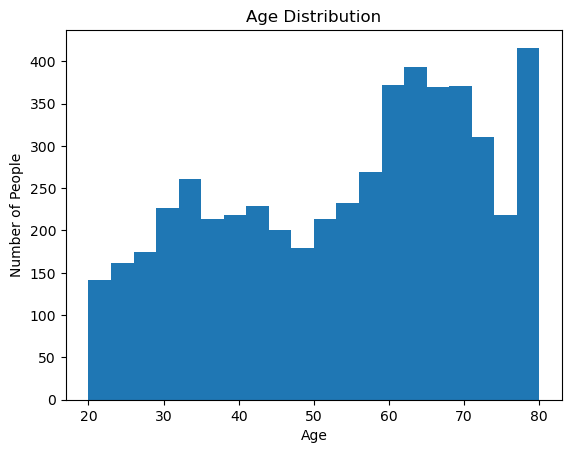

In [137]:
# age 
plt.hist(merge_df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.show()


In [136]:
# write to csv file
merge_df.to_csv('NHANES/NHANES_2021_2023.csv', index=False)

#### Write Json file to store selected meta data from NHANES 2021-2023

In [925]:
# File path for the JSON file
json_file_path = os.path.join(data_path, 'NHANES_metadata.json')

# Write the dictionary to a JSON file
with open(json_file_path, 'w') as json_file:
    json.dump(variables_meta, json_file, indent=4)